In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [7]:
iris = load_iris()
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
y = iris.target

<Axes: >

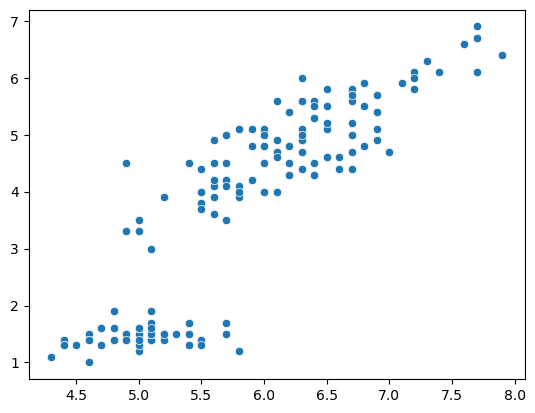

In [8]:
iris = load_iris()
X = iris.data
y = iris.target

sns.scatterplot(x=X[:, 0], y=X[:, 2])

In [9]:
# scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [10]:
# dimensionality reduction

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

In [11]:
# elbow method

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)



3


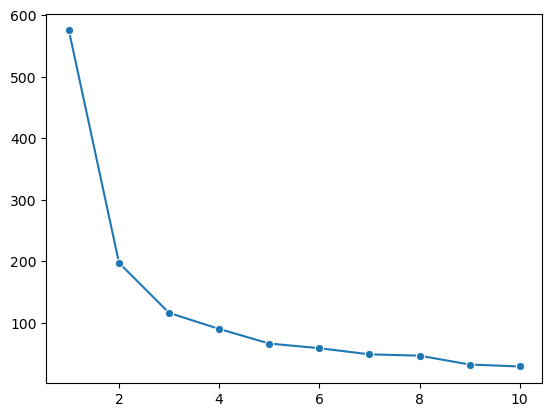

In [12]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')  

from kneed import KneeLocator

knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
print(knee.knee)

<Axes: >

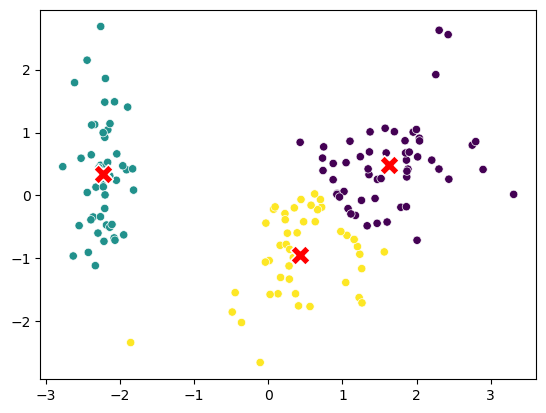

In [13]:
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:, 1], marker='X', s=200, c='red')

<Axes: >

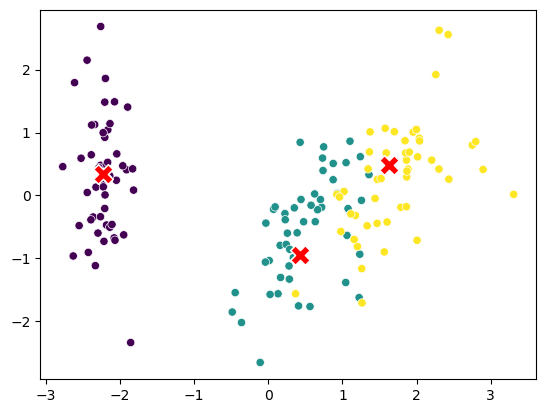

In [14]:
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=y)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X')